# DJF Running Correlation: ONI vs Indonesia Regional Rainfall Anomalies
This notebook computes DJF (Dec-Jan-Feb) regional rainfall anomalies and centered running correlations with DJF ONI for 1979-2020, using multiple precipitation datasets on native grids.

In [11]:
from pathlib import Path
import os

os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.mplconfig'))

import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import cartopy.crs as ccrs
import cartopy.feature as cfeature

warnings.filterwarnings('ignore', category=FutureWarning)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25


In [12]:
# ----------------------------
# User Config
# ----------------------------
START_YEAR = 1979
END_YEAR = 2020
WINDOWS = [9, 15]
MIN_VALID_FRACTION = 0.70

BASE_DATA_DIR = Path('/Users/rizzie/Academic/9_TugasAkhir/data/all_data')
WORK_DIR = Path('/Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation')
FIG_DIR = WORK_DIR / 'figures'
CSV_DIR = WORK_DIR / 'csv'

FIG_DIR.mkdir(parents=True, exist_ok=True)
CSV_DIR.mkdir(parents=True, exist_ok=True)

# Fixed plot style for each dataset (used in all running-correlation figures)
DATASET_STYLES = {
    'MSWEP': {'color': '#1f77b4', 'marker': 'o'},
    'ERA5': {'color': '#ff7f0e', 'marker': 's'},
    'GPCC': {'color': '#2ca02c', 'marker': '^'},
    'GPCP': {'color': '#d62728', 'marker': 'D'},
    'CHIRPS': {'color': '#9467bd', 'marker': 'P'},
}

# Dataset-specific config: path, var name, coord hints, and optional units conversion
# unit_conversion options: none, m_to_mm, mm_day_to_mm_month, m_day_to_mm_month
DATASETS = {
    'MSWEP': {
        'path': BASE_DATA_DIR / 'mswep.nc',
        'var_name': 'precipitation',
        'coord_names': {'time': None, 'lat': None, 'lon': None},
        'unit_conversion': 'none',
    },
    'ERA5': {
        'path': BASE_DATA_DIR / 'era5.nc',
        'var_name': 'tp',
        'coord_names': {'time': 'valid_time', 'lat': 'latitude', 'lon': 'longitude'},
        'unit_conversion': 'm_to_mm',
    },
    'GPCC': {
        'path': BASE_DATA_DIR / 'gpcc.nc',
        'var_name': 'precip',
        'coord_names': {'time': 'time', 'lat': 'lat', 'lon': 'lon'},
        'unit_conversion': 'none',
    },
    'GPCP': {
        'path': BASE_DATA_DIR / 'gpcp.nc',
        'var_name': 'precip',
        'coord_names': {'time': 'time', 'lat': 'lat', 'lon': 'lon'},
        'unit_conversion': 'mm_day_to_mm_month',
    },
    'CHIRPS': {
        'path': BASE_DATA_DIR / 'chirps.nc',
        'var_name': 'precip',
        'coord_names': {'time': 'time', 'lat': 'latitude', 'lon': 'longitude'},
        'unit_conversion': 'none',
    },
}

ONI_CONFIG = {
    'path': BASE_DATA_DIR / 'oni.csv',
    'missing_values': [-9999, -9999.0, -99.99],
}

REGIONS = {
    'a_sumatera': {
        'code': 'a',
        'lon_min': 100.0, 'lon_max': 104.0,
        'lat_min': -2.0,  'lat_max': 2.0,
    },
    'b_west_java': {
        'code': 'b1',
        'lon_min': 105.0, 'lon_max': 109.0,
        'lat_min': -9.0,  'lat_max': -5.0,
    },
    'b_east_java': {
        'code': 'b2',
        'lon_min': 111.0, 'lon_max': 115.0,
        'lat_min': -9.0,  'lat_max': -5.0,
    },
    'c_kalimantan': {
        'code': 'c',
        'lon_min': 112.0, 'lon_max': 116.0,
        'lat_min': -3.0,  'lat_max': 1.0,
    },
    'd_central_sulawesi': {
        'code': 'd',
        'lon_min': 120.0, 'lon_max': 124.0,
        'lat_min': -3.0,  'lat_max': 1.0,
    },
    'e_west_papua': {
        'code': 'e',
        'lon_min': 132.0, 'lon_max': 136.0,
        'lat_min': -4.0,  'lat_max': 0.0,
    },
}

MAP_COLORS = {
    'a_sumatera': '#66c2a5',
    'b_west_java': '#fc8d62',
    'b_east_java': '#8da0cb',
    'c_kalimantan': '#e78ac3',
    'd_central_sulawesi': '#a6d854',
    'e_west_papua': '#ffd92f',
}

TIME_CANDIDATES = ('time', 'valid_time')
LAT_CANDIDATES = ('lat', 'latitude', 'y')
LON_CANDIDATES = ('lon', 'longitude', 'x')


In [13]:
def resolve_name(available_names, candidates):
    lookup = {name.lower(): name for name in available_names}
    for c in candidates:
        if c.lower() in lookup:
            return lookup[c.lower()]
    return None


def select_precip_var(ds, dataset_name, configured_var=None):
    if configured_var is not None:
        if configured_var not in ds.data_vars:
            raise KeyError(f"{dataset_name}: variable '{configured_var}' not found. Available: {list(ds.data_vars)}")
        return ds[configured_var], configured_var

    candidates = []
    for var_name in ds.data_vars:
        dims_lower = [d.lower() for d in ds[var_name].dims]
        has_time = any(d in TIME_CANDIDATES for d in dims_lower)
        has_lat = any(d in LAT_CANDIDATES for d in dims_lower)
        has_lon = any(d in LON_CANDIDATES for d in dims_lower)
        if has_time and has_lat and has_lon:
            candidates.append(var_name)

    if not candidates:
        raise ValueError(f"{dataset_name}: no precip variable found automatically. Set var_name in DATASETS config.")

    return ds[candidates[0]], candidates[0]


def convert_precip_units(da, conversion_mode):
    if conversion_mode == 'none':
        out = da
    elif conversion_mode == 'm_to_mm':
        out = da * 1000.0
    elif conversion_mode == 'mm_day_to_mm_month':
        out = da * da['time'].dt.days_in_month
    elif conversion_mode == 'm_day_to_mm_month':
        out = da * 1000.0 * da['time'].dt.days_in_month
    else:
        raise ValueError(f"Unsupported unit conversion: {conversion_mode}")

    out.attrs = dict(da.attrs)
    out.attrs['units'] = 'mm/month'
    out.name = da.name
    return out


def standardize_precip_da(ds, dataset_name, cfg):
    da, used_var = select_precip_var(ds, dataset_name, cfg.get('var_name'))

    available = list(da.coords) + list(da.dims)
    hints = cfg.get('coord_names', {})

    time_name = hints.get('time') or resolve_name(available, TIME_CANDIDATES)
    lat_name = hints.get('lat') or resolve_name(available, LAT_CANDIDATES)
    lon_name = hints.get('lon') or resolve_name(available, LON_CANDIDATES)

    if any(name is None for name in (time_name, lat_name, lon_name)):
        raise ValueError(
            f"{dataset_name}: could not resolve coordinate names. Found coords={list(da.coords)} dims={list(da.dims)}"
        )

    rename_map = {}
    if time_name != 'time':
        rename_map[time_name] = 'time'
    if lat_name != 'lat':
        rename_map[lat_name] = 'lat'
    if lon_name != 'lon':
        rename_map[lon_name] = 'lon'

    if rename_map:
        da = da.rename(rename_map)

    # Reduce extra dims (e.g., member/expver) by taking the first index.
    extra_dims = [d for d in da.dims if d not in ('time', 'lat', 'lon')]
    for d in extra_dims:
        da = da.isel({d: 0}, drop=True)

    # Standardize monthly timestamps and remove duplicates.
    da = da.assign_coords(time=pd.to_datetime(da['time'].values))
    da = da.sortby('time')

    time_index = pd.DatetimeIndex(da['time'].values)
    if time_index.has_duplicates:
        _, keep_idx = np.unique(time_index.values, return_index=True)
        da = da.isel(time=np.sort(keep_idx))

    # Keep native longitude coordinates; region bounds are mapped to native convention in subset_region.

    da = convert_precip_units(da, cfg.get('unit_conversion', 'none'))

    # Needed monthly span to form DJF labels from START_YEAR..END_YEAR
    start_time = pd.Timestamp(START_YEAR - 1, 12, 1)
    end_time = pd.Timestamp(END_YEAR, 2, 28)
    da = da.sel(time=slice(start_time, end_time))

    print(f"{dataset_name}: using var='{used_var}', shape={tuple(da.shape)}, time[{da['time'].size}]")
    return da


def subset_region(da, region):
    lat_min = min(region['lat_min'], region['lat_max'])
    lat_max = max(region['lat_min'], region['lat_max'])

    # Match region longitude bounds to dataset native convention (-180..180 or 0..360).
    lon_vals = da['lon'].values
    lon_data_min = float(np.nanmin(lon_vals))
    lon_data_max = float(np.nanmax(lon_vals))

    lon_min = float(region['lon_min'])
    lon_max = float(region['lon_max'])

    if lon_data_max <= 180.0:
        lon_min = ((lon_min + 180.0) % 360.0) - 180.0
        lon_max = ((lon_max + 180.0) % 360.0) - 180.0
    else:
        lon_min = lon_min % 360.0
        lon_max = lon_max % 360.0

    lon_min, lon_max = min(lon_min, lon_max), max(lon_min, lon_max)

    lat0 = float(da['lat'].values[0])
    lat1 = float(da['lat'].values[-1])
    lat_slice = slice(lat_min, lat_max) if lat0 <= lat1 else slice(lat_max, lat_min)

    lon0 = float(da['lon'].values[0])
    lon1 = float(da['lon'].values[-1])
    lon_slice = slice(lon_min, lon_max) if lon0 <= lon1 else slice(lon_max, lon_min)

    sub = da.sel(lat=lat_slice, lon=lon_slice)
    return sub


def compute_regional_monthly_mean(da, region, min_valid_fraction=0.70):
    sub = subset_region(da, region)

    if sub.sizes.get('lat', 0) == 0 or sub.sizes.get('lon', 0) == 0:
        return pd.Series(dtype=float, name='rain_mm_month')

    n_cells = sub.sizes['lat'] * sub.sizes['lon']
    valid_fraction = sub.notnull().sum(dim=('lat', 'lon')) / n_cells

    regional_mean = sub.mean(dim=('lat', 'lon'), skipna=True).where(valid_fraction >= min_valid_fraction)

    series = regional_mean.to_series()
    series.index = pd.to_datetime(series.index)
    series = series.sort_index()
    series = series[~series.index.duplicated(keep='first')]
    series.name = 'rain_mm_month'
    return series


def monthly_to_djf_series(monthly_series, start_year, end_year):
    if monthly_series.empty:
        out = pd.Series(index=np.arange(start_year, end_year + 1), dtype=float, name='djf_mean')
        out.index.name = 'year'
        return out

    s = monthly_series.copy()
    s.index = pd.to_datetime(s.index)

    # Collapse any duplicates to unique monthly timestamps.
    s = s.groupby(s.index.to_period('M')).mean()
    s.index = s.index.to_timestamp(how='start')

    df = s.to_frame('value').reset_index().rename(columns={'index': 'time'})
    df['year'] = df['time'].dt.year
    df['month'] = df['time'].dt.month

    df = df[df['month'].isin([12, 1, 2])]
    df['djf_year'] = np.where(df['month'] == 12, df['year'] + 1, df['year'])

    records = []
    for year in range(start_year, end_year + 1):
        g = df[df['djf_year'] == year]
        complete = (
            len(g) == 3
            and set(g['month'].tolist()) == {12, 1, 2}
            and g['value'].notna().all()
        )
        records.append((year, g['value'].mean() if complete else np.nan))

    out = pd.Series(dict(records), name='djf_mean')
    out.index.name = 'year'
    return out


def load_oni_monthly(oni_path, missing_values=None):
    df = pd.read_csv(oni_path)
    df.columns = [c.strip().lower() for c in df.columns]

    if {'year', 'month', 'oni'}.issubset(df.columns):
        tmp = df[['year', 'month', 'oni']].copy()
        tmp['year'] = pd.to_numeric(tmp['year'], errors='coerce')
        tmp['month'] = pd.to_numeric(tmp['month'], errors='coerce')
        tmp['oni'] = pd.to_numeric(tmp['oni'], errors='coerce')
        tmp['time'] = pd.to_datetime(
            dict(year=tmp['year'], month=tmp['month'], day=1), errors='coerce'
        )
    elif {'date', 'oni'}.issubset(df.columns):
        tmp = df[['date', 'oni']].copy()
        tmp['time'] = pd.to_datetime(tmp['date'], errors='coerce')
        tmp['oni'] = pd.to_numeric(tmp['oni'], errors='coerce')
    else:
        raise ValueError(
            f"ONI CSV must contain either [year, month, oni] or [date, oni]. Found columns: {list(df.columns)}"
        )

    if missing_values is not None and len(missing_values) > 0:
        tmp['oni'] = tmp['oni'].replace(missing_values, np.nan)

    tmp = tmp.dropna(subset=['time'])
    tmp['time'] = tmp['time'].dt.to_period('M').dt.to_timestamp(how='start')

    # Average if duplicate monthly rows exist.
    tmp = tmp.groupby('time', as_index=False)['oni'].mean().sort_values('time')

    start_time = pd.Timestamp(START_YEAR - 1, 12, 1)
    end_time = pd.Timestamp(END_YEAR, 2, 28)
    tmp = tmp[(tmp['time'] >= start_time) & (tmp['time'] <= end_time)]

    s = tmp.set_index('time')['oni']
    s.name = 'oni'
    return s


def centered_running_correlation(x, y, window, start_year, end_year):
    if window % 2 == 0:
        raise ValueError('Window length must be odd for centered running correlations.')

    years = pd.Index(np.arange(start_year, end_year + 1), name='year')
    x = x.reindex(years)
    y = y.reindex(years)

    half = window // 2
    out = []

    for center_year in years:
        y0 = center_year - half
        y1 = center_year + half

        if y0 < start_year or y1 > end_year:
            continue

        xw = x.loc[y0:y1]
        yw = y.loc[y0:y1]
        valid = xw.notna() & yw.notna()

        corr = xw[valid].corr(yw[valid]) if valid.sum() == window else np.nan
        out.append((center_year, corr))

    s = pd.Series(dict(out), name='correlation')
    s.index.name = 'year'
    return s


In [14]:
# ----------------------------
# Load ONI and compute DJF ONI
# ----------------------------
oni_monthly = load_oni_monthly(ONI_CONFIG['path'], ONI_CONFIG.get('missing_values'))
oni_djf = monthly_to_djf_series(oni_monthly, START_YEAR, END_YEAR).rename('oni_djf')

oni_djf_df = oni_djf.reset_index()
oni_csv_path = CSV_DIR / f'oni_djf_{START_YEAR}_{END_YEAR}.csv'
oni_djf_df.to_csv(oni_csv_path, index=False)

print(f'Saved DJF ONI: {oni_csv_path}')
print(oni_djf_df.head())


Saved DJF ONI: /Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/csv/oni_djf_1979_2020.csv
   year   oni_djf
0  1979  0.033333
1  1980  0.563333
2  1981 -0.256667
3  1982 -0.020000
4  1983  2.110000


In [15]:
# ----------------------------
# Process each rainfall dataset
# - regional monthly mean (native grid, no area weighting, no regridding)
# - DJF series with Jan-year labels
# - anomalies relative to 1979-2020 DJF mean
# ----------------------------
regional_records = []
rain_djf = {dataset: {} for dataset in DATASETS}
rain_anom = {dataset: {} for dataset in DATASETS}

for dataset_name, cfg in DATASETS.items():
    print(f'\nProcessing {dataset_name} ...')
    ds = xr.open_dataset(cfg['path'], decode_times=True)

    try:
        da = standardize_precip_da(ds, dataset_name, cfg)

        for region_name, region in REGIONS.items():
            monthly_mean = compute_regional_monthly_mean(
                da, region, min_valid_fraction=MIN_VALID_FRACTION
            )
            djf_series = monthly_to_djf_series(monthly_mean, START_YEAR, END_YEAR)
            anomaly = djf_series - djf_series.mean(skipna=True)

            rain_djf[dataset_name][region_name] = djf_series
            rain_anom[dataset_name][region_name] = anomaly

            for year in range(START_YEAR, END_YEAR + 1):
                regional_records.append(
                    {
                        'dataset': dataset_name,
                        'region': region_name,
                        'region_code': region['code'],
                        'year': year,
                        'djf_rain_mm_month': djf_series.loc[year],
                        'djf_anomaly_mm_month': anomaly.loc[year],
                    }
                )

    finally:
        ds.close()

regional_djf_df = pd.DataFrame(regional_records).sort_values(['dataset', 'region', 'year'])
regional_csv_path = CSV_DIR / f'regional_djf_rainfall_anomalies_{START_YEAR}_{END_YEAR}.csv'
regional_djf_df.to_csv(regional_csv_path, index=False)

print(f'\nSaved regional DJF rainfall and anomalies: {regional_csv_path}')
regional_djf_df.head()



Processing MSWEP ...
MSWEP: using var='precipitation', shape=(248, 190, 480), time[248]

Processing ERA5 ...
ERA5: using var='tp', shape=(495, 721, 1440), time[495]

Processing GPCC ...
GPCC: using var='precip', shape=(495, 720, 1440), time[495]

Processing GPCP ...
GPCP: using var='precip', shape=(494, 72, 144), time[494]

Processing CHIRPS ...
CHIRPS: using var='precip', shape=(470, 2400, 7200), time[470]

Saved regional DJF rainfall and anomalies: /Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/csv/regional_djf_rainfall_anomalies_1979_2020.csv


,dataset,region,region_code,year,djf_rain_mm_month,djf_anomaly_mm_month
1008,CHIRPS,a_sumatera,a,1979,NaN,NaN
1009,CHIRPS,a_sumatera,a,1980,NaN,NaN
1010,CHIRPS,a_sumatera,a,1981,NaN,NaN
1011,CHIRPS,a_sumatera,a,1982,167.186768,-76.522756
1012,CHIRPS,a_sumatera,a,1983,205.974045,-37.735479


In [16]:
# ----------------------------
# Compute centered running correlations
# ----------------------------
running_records = []
running_corr = {w: {dataset: {} for dataset in DATASETS} for w in WINDOWS}

for window in WINDOWS:
    for dataset_name in DATASETS:
        for region_name in REGIONS:
            corr_series = centered_running_correlation(
                rain_anom[dataset_name][region_name],
                oni_djf,
                window=window,
                start_year=START_YEAR,
                end_year=END_YEAR,
            )

            running_corr[window][dataset_name][region_name] = corr_series

            for year, corr_val in corr_series.items():
                running_records.append(
                    {
                        'window_years': window,
                        'dataset': dataset_name,
                        'region': region_name,
                        'region_code': REGIONS[region_name]['code'],
                        'year': int(year),
                        'correlation': corr_val,
                    }
                )

running_df = pd.DataFrame(running_records).sort_values(
    ['window_years', 'region', 'dataset', 'year']
)
running_csv_path = CSV_DIR / f'running_correlations_djf_oni_{START_YEAR}_{END_YEAR}.csv'
running_df.to_csv(running_csv_path, index=False)

print(f'Saved running correlations: {running_csv_path}')
running_df.head()


Saved running correlations: /Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/csv/running_correlations_djf_oni_1979_2020.csv


,window_years,dataset,region,region_code,year,correlation
816,9,CHIRPS,a_sumatera,a,1983,NaN
817,9,CHIRPS,a_sumatera,a,1984,NaN
818,9,CHIRPS,a_sumatera,a,1985,NaN
819,9,CHIRPS,a_sumatera,a,1986,-0.450707
820,9,CHIRPS,a_sumatera,a,1987,-0.574527


In [17]:
# ----------------------------
# Study area map with analysis boxes
# ----------------------------
map_path = FIG_DIR / 'study_area_indonesia_boxes.png'

fig = plt.figure(figsize=(11, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([95, 145, -15, 10], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='0.95')
ax.add_feature(cfeature.OCEAN, facecolor='white')
ax.add_feature(cfeature.COASTLINE.with_scale('110m'), linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale('110m'), linewidth=0.5, linestyle=':')

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.6, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.x_inline = False
gl.y_inline = False

for region_name, region in REGIONS.items():
    lon_min, lon_max = region['lon_min'], region['lon_max']
    lat_min, lat_max = region['lat_min'], region['lat_max']

    rect = Rectangle(
        (lon_min, lat_min),
        lon_max - lon_min,
        lat_max - lat_min,
        facecolor=MAP_COLORS[region_name],
        edgecolor='black',
        linewidth=1.3,
        alpha=0.35,
        transform=ccrs.PlateCarree(),
        zorder=3,
    )
    ax.add_patch(rect)

    lon_c = 0.5 * (lon_min + lon_max)
    lat_c = 0.5 * (lat_min + lat_max)
    ax.text(
        lon_c, lat_c, region['code'],
        transform=ccrs.PlateCarree(),
        fontsize=11, fontweight='bold', ha='center', va='center',
        zorder=4
    )

ax.set_title('Study Area and Analysis Boxes (Indonesia Subregions)')
fig.savefig(map_path, bbox_inches='tight')
plt.close(fig)

print(f'Saved map figure: {map_path}')


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


Saved map figure: /Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/figures/study_area_indonesia_boxes.png


In [18]:
# ----------------------------
# Running-correlation figures by region and window
# ----------------------------
for region_name, region in REGIONS.items():
    for window in WINDOWS:
        subset = running_df[(running_df['region'] == region_name) & (running_df['window_years'] == window)].copy()

        pivot = subset.pivot(index='year', columns='dataset', values='correlation').sort_index()

        fig, ax = plt.subplots(figsize=(11, 5))

        # Envelope (min-max) and median across datasets
        min_series = pivot.min(axis=1, skipna=True)
        max_series = pivot.max(axis=1, skipna=True)
        med_series = pivot.median(axis=1, skipna=True)

        ax.fill_between(
            pivot.index.values,
            min_series.values,
            max_series.values,
            color='0.7', alpha=0.35, label='Dataset min-max'
        )
        ax.plot(
            pivot.index.values,
            med_series.values,
            color='black', linewidth=2.0, label='Dataset median'
        )

        # Dataset-specific scatter points
        for dataset_name, style in DATASET_STYLES.items():
            ds_plot = subset[subset['dataset'] == dataset_name]
            ax.scatter(
                ds_plot['year'],
                ds_plot['correlation'],
                color=style['color'],
                marker=style['marker'],
                s=38,
                alpha=0.95,
                label=dataset_name,
            )

        ax.axhline(0.0, color='0.2', linewidth=1.0, linestyle='--')

        half = window // 2
        ax.set_xlim(START_YEAR + half - 0.5, END_YEAR - half + 0.5)
        ax.set_ylim(-1, 1)

        ax.set_xlabel('Center DJF year')
        ax.set_ylabel('Pearson correlation (r)')
        ax.set_title(
            f"DJF Running Correlation: ONI vs Rainfall Anomaly | {region_name} ({region['code']}), {window}-year window"
        )

        # De-duplicate legend labels
        handles, labels = ax.get_legend_handles_labels()
        dedup = {}
        for h, l in zip(handles, labels):
            if l not in dedup:
                dedup[l] = h
        ax.legend(dedup.values(), dedup.keys(), loc='best', ncol=3, frameon=False, fontsize=9)

        out_path = FIG_DIR / f'runningcorr_djf_oni_{region_name}_{window}yr.png'
        fig.savefig(out_path, bbox_inches='tight')
        plt.close(fig)

        print(f'Saved: {out_path}')


Saved: /Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/figures/runningcorr_djf_oni_a_sumatera_9yr.png
Saved: /Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/figures/runningcorr_djf_oni_a_sumatera_15yr.png
Saved: /Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/figures/runningcorr_djf_oni_b_west_java_9yr.png
Saved: /Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/figures/runningcorr_djf_oni_b_west_java_15yr.png
Saved: /Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/figures/runningcorr_djf_oni_b_east_java_9yr.png
Saved: /Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/figures/runningcorr_djf_oni_b_east_java_15yr.png
Saved: /Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/figures/runningcorr_djf_oni_c_kalimantan_9yr.png
Saved: /Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/figures/runningcorr_djf_oni_c_kalimantan_15yr.png
Saved: /Users/rizzie/Academic/9_TugasAkhir/n

In [19]:
print('\nAll outputs generated.')
print(f'Figures folder: {FIG_DIR}')
print(f'CSV folder: {CSV_DIR}')



All outputs generated.
Figures folder: /Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/figures
CSV folder: /Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/csv


## Additional Multi-Region DJF Running Correlation Layouts
Appended cells below build a consolidated tidy table, derive `java_combined`, compute cross-dataset summaries, and create Layout A/B/C figures for window 9 and 15.

In [20]:
# ----------------------------
# Consolidate running-correlation output into tidy format + derive java_combined
# ----------------------------
REGION_ORDER_5 = [
    'riau_sumatera',
    'java_combined',
    'kalimantan',
    'central_sulawesi',
    'west_papua',
]

REGION_DISPLAY_NAMES = {
    'riau_sumatera': 'Riau Sumatera',
    'java_combined': 'Java (Combined)',
    'kalimantan': 'Kalimantan',
    'central_sulawesi': 'Central Sulawesi',
    'west_papua': 'West Papua',
}

DATASET_ORDER = ['MSWEP', 'ERA5', 'GPCC', 'GPCP', 'CHIRPS']

# One global style mapping for all scatter plots in layouts A/B (fixed color + marker).
DATASET_STYLES_GLOBAL = {
    'MSWEP': {'color': '#1f77b4', 'marker': 'o'},
    'ERA5': {'color': '#ff7f0e', 'marker': 's'},
    'GPCC': {'color': '#2ca02c', 'marker': '^'},
    'GPCP': {'color': '#d62728', 'marker': 'D'},
    'CHIRPS': {'color': '#9467bd', 'marker': 'P'},
}

# Small, fixed dataset jitter in x (years).
DATASET_X_JITTER = {
    'MSWEP': -0.18,
    'ERA5': -0.09,
    'GPCC': 0.00,
    'GPCP': 0.09,
    'CHIRPS': 0.18,
}

if 'running_df' in globals():
    _run_src = running_df.copy()
else:
    _run_csv = CSV_DIR / f'running_correlations_djf_oni_{START_YEAR}_{END_YEAR}.csv'
    if not _run_csv.exists():
        raise FileNotFoundError(
            f"running_df is not in memory and CSV not found: {_run_csv}. Execute previous running-correlation cells first."
        )
    _run_src = pd.read_csv(_run_csv)

# Normalize column names to required tidy schema.
rename_map = {}
if 'year' in _run_src.columns:
    rename_map['year'] = 'year_center'
if 'window_years' in _run_src.columns:
    rename_map['window_years'] = 'window'
if 'correlation' in _run_src.columns:
    rename_map['correlation'] = 'corr'
_run_src = _run_src.rename(columns=rename_map)

required_cols = ['year_center', 'window', 'dataset', 'region', 'corr']
missing_cols = [c for c in required_cols if c not in _run_src.columns]
if missing_cols:
    raise ValueError(f"Missing required columns after normalization: {missing_cols}")

run_corr_tidy = _run_src[required_cols].copy()
run_corr_tidy['year_center'] = pd.to_numeric(run_corr_tidy['year_center'], errors='coerce')
run_corr_tidy['window'] = pd.to_numeric(run_corr_tidy['window'], errors='coerce')
run_corr_tidy['corr'] = pd.to_numeric(run_corr_tidy['corr'], errors='coerce')
run_corr_tidy = run_corr_tidy.dropna(subset=['year_center', 'window', 'dataset', 'region'])
run_corr_tidy['year_center'] = run_corr_tidy['year_center'].astype(int)
run_corr_tidy['window'] = run_corr_tidy['window'].astype(int)
run_corr_tidy['dataset'] = run_corr_tidy['dataset'].astype(str)
run_corr_tidy['region'] = run_corr_tidy['region'].astype(str)
run_corr_tidy = run_corr_tidy[run_corr_tidy['window'].isin([9, 15])].copy()

# Keep original region keys intact in run_corr_tidy; build a derived plotting table with exactly 5 target regions.
region_alias_to_plot = {
    'a_sumatera': 'riau_sumatera',
    'riau_sumatera': 'riau_sumatera',
    'c_kalimantan': 'kalimantan',
    'kalimantan': 'kalimantan',
    'd_central_sulawesi': 'central_sulawesi',
    'central_sulawesi': 'central_sulawesi',
    'e_west_papua': 'west_papua',
    'west_papua': 'west_papua',
}

west_java_keys = ['b_west_java', 'west_java']
east_java_keys = ['b_east_java', 'east_java']

non_java_plot = run_corr_tidy.copy()
non_java_plot['region'] = non_java_plot['region'].map(region_alias_to_plot)
non_java_plot = non_java_plot.dropna(subset=['region'])
non_java_plot = non_java_plot[non_java_plot['region'] != 'java_combined']

west_java = run_corr_tidy[run_corr_tidy['region'].isin(west_java_keys)].copy()
east_java = run_corr_tidy[run_corr_tidy['region'].isin(east_java_keys)].copy()

west_java = west_java.groupby(['year_center', 'window', 'dataset'], as_index=False)['corr'].mean()
east_java = east_java.groupby(['year_center', 'window', 'dataset'], as_index=False)['corr'].mean()

java_merge = west_java.merge(
    east_java,
    on=['year_center', 'window', 'dataset'],
    how='outer',
    suffixes=('_west', '_east'),
)

java_merge['corr'] = np.where(
    java_merge['corr_west'].notna() & java_merge['corr_east'].notna(),
    0.5 * (java_merge['corr_west'] + java_merge['corr_east']),
    np.nan,
)

java_combined = java_merge[['year_center', 'window', 'dataset', 'corr']].copy()
java_combined['region'] = 'java_combined'

run_corr_plot_df = pd.concat(
    [non_java_plot[['year_center', 'window', 'dataset', 'region', 'corr']], java_combined],
    ignore_index=True,
)

run_corr_plot_df = run_corr_plot_df[run_corr_plot_df['region'].isin(REGION_ORDER_5)].copy()
run_corr_plot_df = run_corr_plot_df[run_corr_plot_df['dataset'].isin(DATASET_ORDER)].copy()
run_corr_plot_df = run_corr_plot_df.drop_duplicates(
    subset=['year_center', 'window', 'dataset', 'region'],
    keep='first',
)
run_corr_plot_df = run_corr_plot_df.sort_values(['window', 'region', 'dataset', 'year_center']).reset_index(drop=True)

# Save tidy and plotting tables for reproducibility.
run_corr_tidy_path = CSV_DIR / f'runningcorr_tidy_all_regions_{START_YEAR}_{END_YEAR}.csv'
run_corr_plot_path = CSV_DIR / f'runningcorr_tidy_plot_regions5_{START_YEAR}_{END_YEAR}.csv'
run_corr_tidy.to_csv(run_corr_tidy_path, index=False)
run_corr_plot_df.to_csv(run_corr_plot_path, index=False)

print(f'Saved tidy all-regions table: {run_corr_tidy_path}')
print(f'Saved tidy 5-region plotting table: {run_corr_plot_path}')
print('Plot regions present:', sorted(run_corr_plot_df['region'].unique()))
print(run_corr_plot_df.head().to_string(index=False))


Saved tidy all-regions table: /Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/csv/runningcorr_tidy_all_regions_1979_2020.csv
Saved tidy 5-region plotting table: /Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/csv/runningcorr_tidy_plot_regions5_1979_2020.csv
Plot regions present: ['central_sulawesi', 'java_combined', 'kalimantan', 'riau_sumatera', 'west_papua']
 year_center  window dataset           region  corr
        1983       9  CHIRPS central_sulawesi   NaN
        1984       9  CHIRPS central_sulawesi   NaN
        1985       9  CHIRPS central_sulawesi   NaN
        1986       9  CHIRPS central_sulawesi   NaN
        1987       9  CHIRPS central_sulawesi   NaN


In [21]:
# ----------------------------
# Cross-dataset summaries by (window, region, year_center)
# ----------------------------
run_corr_summary_df = (
    run_corr_plot_df
    .groupby(['window', 'region', 'year_center'], as_index=False)
    .agg(
        median_corr=('corr', 'median'),
        spread_min=('corr', 'min'),
        spread_max=('corr', 'max'),
        q25=('corr', lambda x: x.quantile(0.25)),
        q75=('corr', lambda x: x.quantile(0.75)),
        n_dataset=('corr', 'count'),
    )
)
run_corr_summary_df['spread_range'] = run_corr_summary_df['spread_max'] - run_corr_summary_df['spread_min']
run_corr_summary_df = run_corr_summary_df.sort_values(['window', 'region', 'year_center']).reset_index(drop=True)

summary_csv_path = CSV_DIR / f'runningcorr_summary_regions5_{START_YEAR}_{END_YEAR}.csv'
run_corr_summary_df.to_csv(summary_csv_path, index=False)

print(f'Saved summary table: {summary_csv_path}')
print(run_corr_summary_df.head().to_string(index=False))


Saved summary table: /Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/csv/runningcorr_summary_regions5_1979_2020.csv
 window           region  year_center  median_corr  spread_min  spread_max       q25       q75  n_dataset  spread_range
      9 central_sulawesi         1983    -0.567789   -0.649181   -0.486396 -0.608485 -0.527092          2      0.162784
      9 central_sulawesi         1984    -0.637289   -0.799921   -0.594545 -0.718605 -0.615917          3      0.205376
      9 central_sulawesi         1985    -0.532186   -0.542381   -0.515012 -0.537284 -0.523599          3      0.027369
      9 central_sulawesi         1986    -0.537439   -0.548023   -0.509032 -0.542731 -0.523235          3      0.038991
      9 central_sulawesi         1987    -0.516726   -0.539135   -0.509608 -0.527931 -0.513167          3      0.029527


In [22]:
# ----------------------------
# Layout A/B/C plotting functions
# ----------------------------
from matplotlib.lines import Line2D

def _dataset_legend_handles():
    handles = []
    for ds in DATASET_ORDER:
        style = DATASET_STYLES_GLOBAL[ds]
        handles.append(
            Line2D(
                [0], [0],
                linestyle='None',
                marker=style['marker'],
                markerfacecolor=style['color'],
                markeredgecolor=style['color'],
                markersize=7,
                label=ds,
            )
        )
    return handles


def plot_layoutA_stacked(window):
    fig, axes = plt.subplots(
        nrows=len(REGION_ORDER_5),
        ncols=1,
        figsize=(13, 12),
        sharex=True,
        sharey=True,
    )

    for ax, region in zip(axes, REGION_ORDER_5):
        dsub = run_corr_plot_df[(run_corr_plot_df['window'] == window) & (run_corr_plot_df['region'] == region)].copy()
        ssub = run_corr_summary_df[(run_corr_summary_df['window'] == window) & (run_corr_summary_df['region'] == region)].copy()
        ssub = ssub.sort_values('year_center')

        if not ssub.empty:
            ax.fill_between(
                ssub['year_center'].values,
                ssub['spread_min'].values,
                ssub['spread_max'].values,
                color='0.65',
                alpha=0.35,
                linewidth=0.0,
                zorder=1,
            )
            ax.plot(
                ssub['year_center'].values,
                ssub['median_corr'].values,
                color='black',
                linewidth=2.3,
                zorder=2,
            )

        for ds in DATASET_ORDER:
            dds = dsub[dsub['dataset'] == ds]
            if dds.empty:
                continue
            style = DATASET_STYLES_GLOBAL[ds]
            x = dds['year_center'].values + DATASET_X_JITTER[ds]
            y = dds['corr'].values
            ax.scatter(
                x, y,
                s=28,
                alpha=0.92,
                color=style['color'],
                marker=style['marker'],
                edgecolor='none',
                zorder=3,
            )

        ax.axhline(0.0, color='0.25', linewidth=0.9, linestyle='--', zorder=0)
        ax.set_ylim(-1.0, 1.0)
        ax.text(
            0.01, 0.86, REGION_DISPLAY_NAMES[region],
            transform=ax.transAxes,
            ha='left', va='center',
            fontsize=11, fontweight='bold',
        )

    axes[-1].set_xlabel('Center DJF year')
    fig.text(0.02, 0.5, 'Pearson correlation (r)', va='center', rotation='vertical')

    fig.suptitle(
        f'DJF Running Correlation: ONI vs Precipitation Anomaly, Window = {window} years, {START_YEAR} to {END_YEAR}',
        y=0.995,
    )

    legend_handles = _dataset_legend_handles()
    fig.legend(
        handles=legend_handles,
        labels=DATASET_ORDER,
        loc='center left',
        bbox_to_anchor=(0.87, 0.5),
        frameon=False,
        title='Dataset',
    )

    fig.tight_layout(rect=[0.04, 0.03, 0.85, 0.975])

    out_path = FIG_DIR / f'DJF_runCorr_window{window:02d}_layoutA_stacked.png'
    fig.savefig(out_path, bbox_inches='tight')
    plt.close(fig)
    return out_path


def plot_layoutB_offset(window):
    region_offsets = {region: 2.4 * i for i, region in enumerate(REGION_ORDER_5)}

    fig, ax = plt.subplots(figsize=(13, 8))

    for region in REGION_ORDER_5:
        off = region_offsets[region]
        dsub = run_corr_plot_df[(run_corr_plot_df['window'] == window) & (run_corr_plot_df['region'] == region)].copy()
        ssub = run_corr_summary_df[(run_corr_summary_df['window'] == window) & (run_corr_summary_df['region'] == region)].copy()
        ssub = ssub.sort_values('year_center')

        if not ssub.empty:
            ax.fill_between(
                ssub['year_center'].values,
                ssub['spread_min'].values + off,
                ssub['spread_max'].values + off,
                color='0.65',
                alpha=0.30,
                linewidth=0.0,
                zorder=1,
            )
            ax.plot(
                ssub['year_center'].values,
                ssub['median_corr'].values + off,
                color='black',
                linewidth=2.1,
                zorder=2,
            )

        for ds in DATASET_ORDER:
            dds = dsub[dsub['dataset'] == ds]
            if dds.empty:
                continue
            style = DATASET_STYLES_GLOBAL[ds]
            ax.scatter(
                dds['year_center'].values + DATASET_X_JITTER[ds],
                dds['corr'].values + off,
                s=24,
                alpha=0.78,
                color=style['color'],
                marker=style['marker'],
                edgecolor='none',
                zorder=3,
            )

        ax.axhline(off, color='0.45', linewidth=0.8, linestyle='-', zorder=0)

    yticks = [region_offsets[r] for r in REGION_ORDER_5]
    ax.set_yticks(yticks)
    ax.set_yticklabels([REGION_DISPLAY_NAMES[r] for r in REGION_ORDER_5])
    ax.set_ylabel('Region (offset; horizontal line is corr = 0)')
    ax.set_xlabel('Center DJF year')

    ax.set_title(
        f'DJF Running Correlation: ONI vs Precipitation Anomaly, Window = {window} years, {START_YEAR} to {END_YEAR} (offset ridgeline)'
    )

    legend_handles = _dataset_legend_handles()
    ax.legend(
        handles=legend_handles,
        labels=DATASET_ORDER,
        loc='center left',
        bbox_to_anchor=(1.01, 0.5),
        frameon=False,
        title='Dataset',
    )

    fig.tight_layout(rect=[0.04, 0.03, 0.84, 0.97])

    out_path = FIG_DIR / f'DJF_runCorr_window{window:02d}_layoutB_offset.png'
    fig.savefig(out_path, bbox_inches='tight')
    plt.close(fig)
    return out_path


def plot_layoutC_heatmap(window):
    ssub = run_corr_summary_df[run_corr_summary_df['window'] == window].copy()
    years = sorted(ssub['year_center'].dropna().astype(int).unique().tolist())

    median_mat = np.full((len(REGION_ORDER_5), len(years)), np.nan, dtype=float)
    spread_mat = np.full((len(REGION_ORDER_5), len(years)), np.nan, dtype=float)

    for i, region in enumerate(REGION_ORDER_5):
        rsub = ssub[ssub['region'] == region].set_index('year_center').sort_index()
        rsub = rsub.reindex(years)
        median_mat[i, :] = rsub['median_corr'].to_numpy()
        spread_mat[i, :] = rsub['spread_range'].to_numpy()

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

    im1 = axes[0].imshow(
        median_mat,
        aspect='auto',
        cmap='RdBu_r',
        vmin=-1.0,
        vmax=1.0,
        interpolation='nearest',
    )
    axes[0].set_yticks(np.arange(len(REGION_ORDER_5)))
    axes[0].set_yticklabels([REGION_DISPLAY_NAMES[r] for r in REGION_ORDER_5])
    axes[0].set_title(f'DJF Running Correlation Median (Window = {window} years)')

    for yline in np.arange(0.5, len(REGION_ORDER_5), 1.0):
        axes[0].axhline(yline, color='white', linewidth=0.7, alpha=0.8)

    cbar1 = fig.colorbar(im1, ax=axes[0], orientation='vertical', pad=0.02)
    cbar1.set_label('Median running correlation')

    spread_vmax = np.nanmax(spread_mat) if np.isfinite(np.nanmax(spread_mat)) else 1.0
    im2 = axes[1].imshow(
        spread_mat,
        aspect='auto',
        cmap='viridis',
        vmin=0.0,
        vmax=spread_vmax,
        interpolation='nearest',
    )
    axes[1].set_yticks(np.arange(len(REGION_ORDER_5)))
    axes[1].set_yticklabels([REGION_DISPLAY_NAMES[r] for r in REGION_ORDER_5])
    axes[1].set_title(f'DJF Dataset Spread (max minus min), Window = {window} years')

    for yline in np.arange(0.5, len(REGION_ORDER_5), 1.0):
        axes[1].axhline(yline, color='white', linewidth=0.7, alpha=0.8)

    if len(years) > 0:
        step = max(1, len(years) // 8)
        tick_idx = np.arange(0, len(years), step)
        axes[1].set_xticks(tick_idx)
        axes[1].set_xticklabels([years[i] for i in tick_idx])
    axes[1].set_xlabel('Center DJF year')

    cbar2 = fig.colorbar(im2, ax=axes[1], orientation='vertical', pad=0.02)
    cbar2.set_label('Dataset spread (max minus min)')

    fig.suptitle(
        f'DJF Running Correlation Heatmap Summary: ONI vs Precipitation Anomaly, Window = {window} years, {START_YEAR} to {END_YEAR}',
        y=0.995,
    )

    fig.tight_layout(rect=[0.04, 0.03, 0.98, 0.97])

    out_path = FIG_DIR / f'DJF_runCorr_window{window:02d}_layoutC_heatmap.png'
    fig.savefig(out_path, bbox_inches='tight')
    # plt.close(fig)
    return out_path


Saved new multi-region layout figures:
/Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/figures/DJF_runCorr_window09_layoutA_stacked.png
/Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/figures/DJF_runCorr_window09_layoutB_offset.png
/Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/figures/DJF_runCorr_window09_layoutC_heatmap.png
/Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/figures/DJF_runCorr_window15_layoutA_stacked.png
/Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/figures/DJF_runCorr_window15_layoutB_offset.png
/Users/rizzie/Academic/9_TugasAkhir/notebook/runningcorrelation/figures/DJF_runCorr_window15_layoutC_heatmap.png


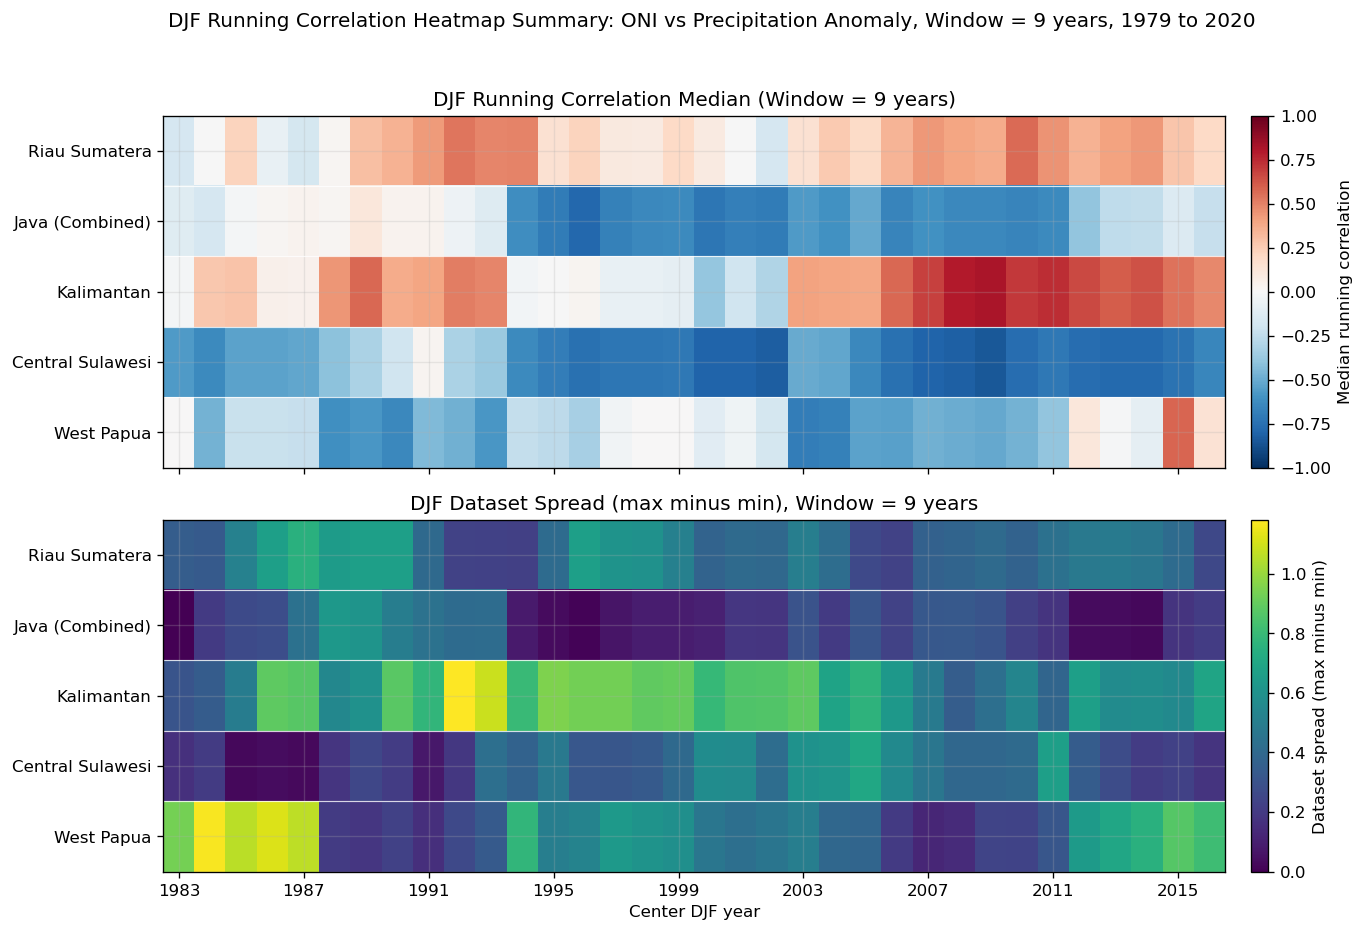

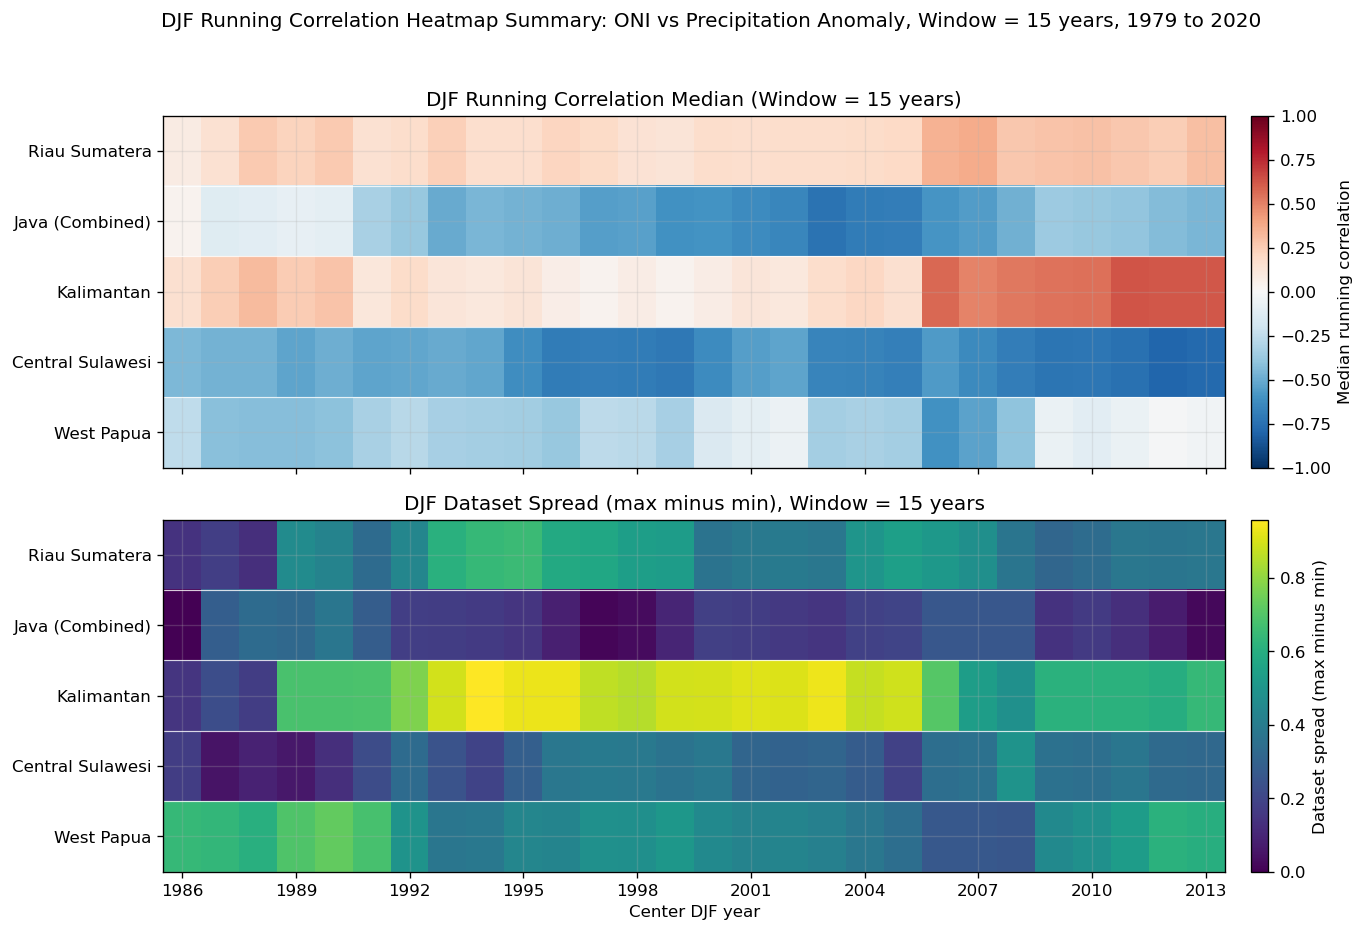

In [23]:
# ----------------------------
# Generate and save Layout A/B/C for windows 9 and 15
# ----------------------------
new_layout_paths = []
for _w in [9, 15]:
    new_layout_paths.append(plot_layoutA_stacked(_w))
    new_layout_paths.append(plot_layoutB_offset(_w))
    new_layout_paths.append(plot_layoutC_heatmap(_w))

print('Saved new multi-region layout figures:')
for _p in new_layout_paths:
    print(_p)
